In [7]:
from google.colab import drive
drive.mount('/content/gdrive')


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [8]:
import os
import cv2
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

In [9]:
# Random Seed
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
#dump = ImageDataGenerator(rescale=1/255)
#train_normal_img.dump()

In [10]:
IMG_SIZE = 128

dataset_path = "/content/gdrive/MyDrive/Projects Btech/DATASET"

normal_path = os.path.join(dataset_path, "normal", "*.jpg")
pothole_path = os.path.join(dataset_path, "potholes", "*.jpg")

In [11]:
def load_images(path, label):
    images = []
    labels = []
    image_paths = glob.glob(path)
    print(f"Loading {label} images...")

    for img_path in image_paths:
        img = cv2.imread(img_path)
        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        images.append(img)
        labels.append(label)
    return images, labels


In [12]:
normal_images, normal_labels = load_images(
    normal_path,
    "NORMAL"
)

Loading NORMAL images...


In [13]:
pothole_images, pothole_labels = load_images(
    pothole_path,
    "POTHOLES"
)


Loading POTHOLES images...


In [14]:
X = np.array(normal_images + pothole_images, dtype=np.float32)
X = X / 255.0
y = normal_labels + pothole_labels
le = LabelEncoder()
Y = le.fit_transform(y)
Y = to_categorical(Y)

print("Dataset Shape :", X.shape)
print("Labels Shape :", Y.shape)

Dataset Shape : (681, 128, 128, 3)
Labels Shape : (681, 2)


In [15]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.25,
    random_state=42,
    stratify=Y
)

print("Training Images :", len(x_train))
print("Testing Images :", len(x_test))

Training Images : 510
Testing Images : 171


In [16]:
model = Sequential()

model.add(Conv2D(32, (5, 5), activation='relu', input_shape=(128, 128, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dropout(0.4))

model.add(Dense(128, activation='relu'))

model.add(Dense(2, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 124, 124, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 455,874 (1.74 MB)

 Trainable params: 455,874 (1.74 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [22]:
history = model.fit(
    x_train,
    y_train,
    epochs=30,
    batch_size=12,
    validation_data=(x_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 23s 526ms/step - accuracy: 0.8431 - loss: 0.3518 - val_accuracy: 0.8129 - val_loss: 0.4155
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 24s 545ms/step - accuracy: 0.8412 - loss: 0.3581 - val_accuracy: 0.8655 - val_loss: 0.3211
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 41s 546ms/step - accuracy: 0.8686 - loss: 0.3094 - val_accuracy: 0.8889 - val_loss: 0.2739
Epoch 4/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 492ms/step - accuracy: 0.9000 - loss: 0.2679 - val_accuracy: 0.8830 - val_loss: 0.2900
Epoch 5/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 502ms/step - accuracy: 0.8922 - loss: 0.2666 - val_accuracy: 0.8713 - val_loss: 0.3459
Epoch 6/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 26s 599ms/step - accuracy: 0.8941 - loss: 0.2404 - val_accuracy: 0.9064 - val_loss: 0.2541
Epoch 7/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 22s 513ms/step - accuracy: 0.9137 - loss: 0.2130 - val_accuracy: 0.8772 - val_loss: 0.3916
Epoch 8/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 24s 569ms/step - accuracy: 0.9098 - loss: 0.2786 - val_accu

In [23]:
model.save("pothole_cnn.keras")

print("\n✅ Model saved successfully as pothole_cnn.keras")


✅ Model saved successfully as pothole_cnn.keras


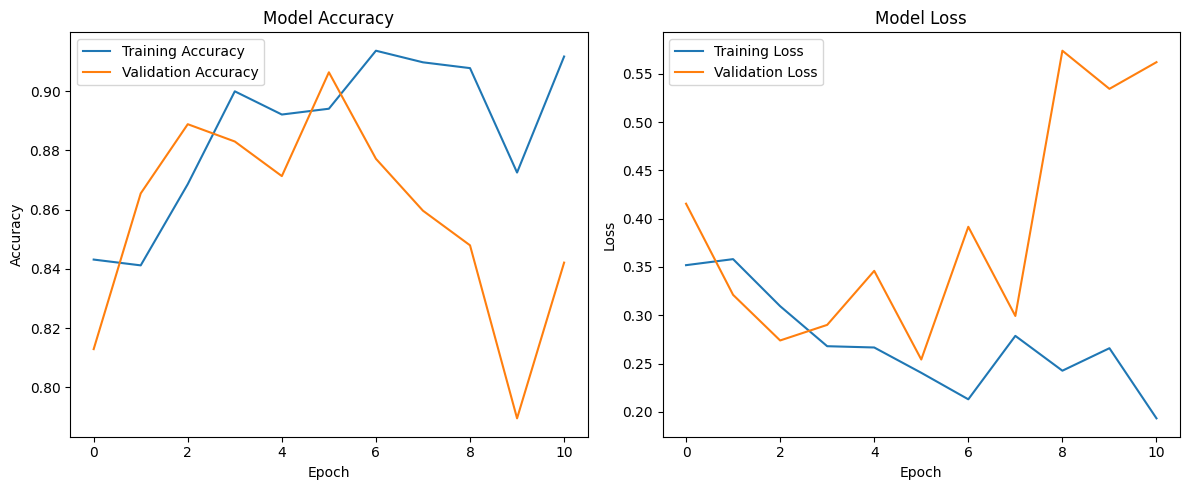

In [24]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()

plt.savefig("accuracy_loss.png")

plt.show()

In [25]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f"\nTest Accuracy : {accuracy * 100:.2f}%")
print(f"Test Loss     : {loss:.4f}")


Test Accuracy : 90.64%
Test Loss     : 0.2541


In [26]:
prediction = model.predict(x_test, verbose=0)

y_pred = np.argmax(prediction, axis=1)
y_true = np.argmax(y_test, axis=1)

classes = ["NORMAL", "POTHOLES"]

In [27]:
print("\nClassification Report\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=classes
    )
)


Classification Report

              precision    recall  f1-score   support

      NORMAL       0.91      0.91      0.91        88
    POTHOLES       0.90      0.90      0.90        83

    accuracy                           0.91       171
   macro avg       0.91      0.91      0.91       171
weighted avg       0.91      0.91      0.91       171



In [28]:
conf_matrix = confusion_matrix(y_true, y_pred)

df_cm = pd.DataFrame(
    conf_matrix,
    index=["Actual NORMAL", "Actual POTHOLES"],
    columns=["Predicted NORMAL", "Predicted POTHOLES"]
)

print("\nConfusion Matrix\n")
print(df_cm)


Confusion Matrix

                 Predicted NORMAL  Predicted POTHOLES
Actual NORMAL                  80                   8
Actual POTHOLES                 8                  75


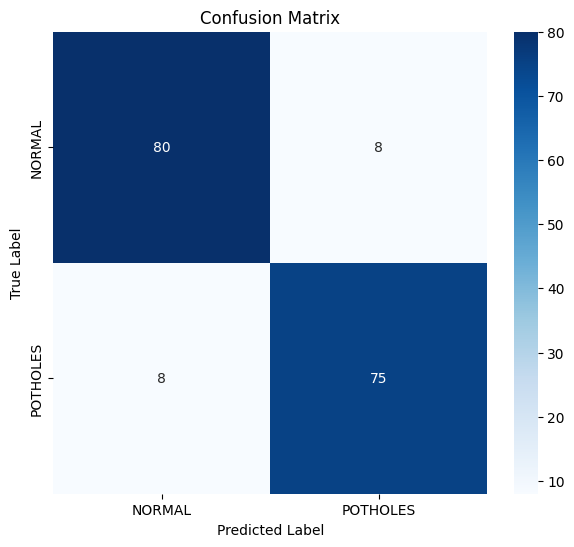

In [29]:
plt.figure(figsize=(7,6))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png")

plt.show()

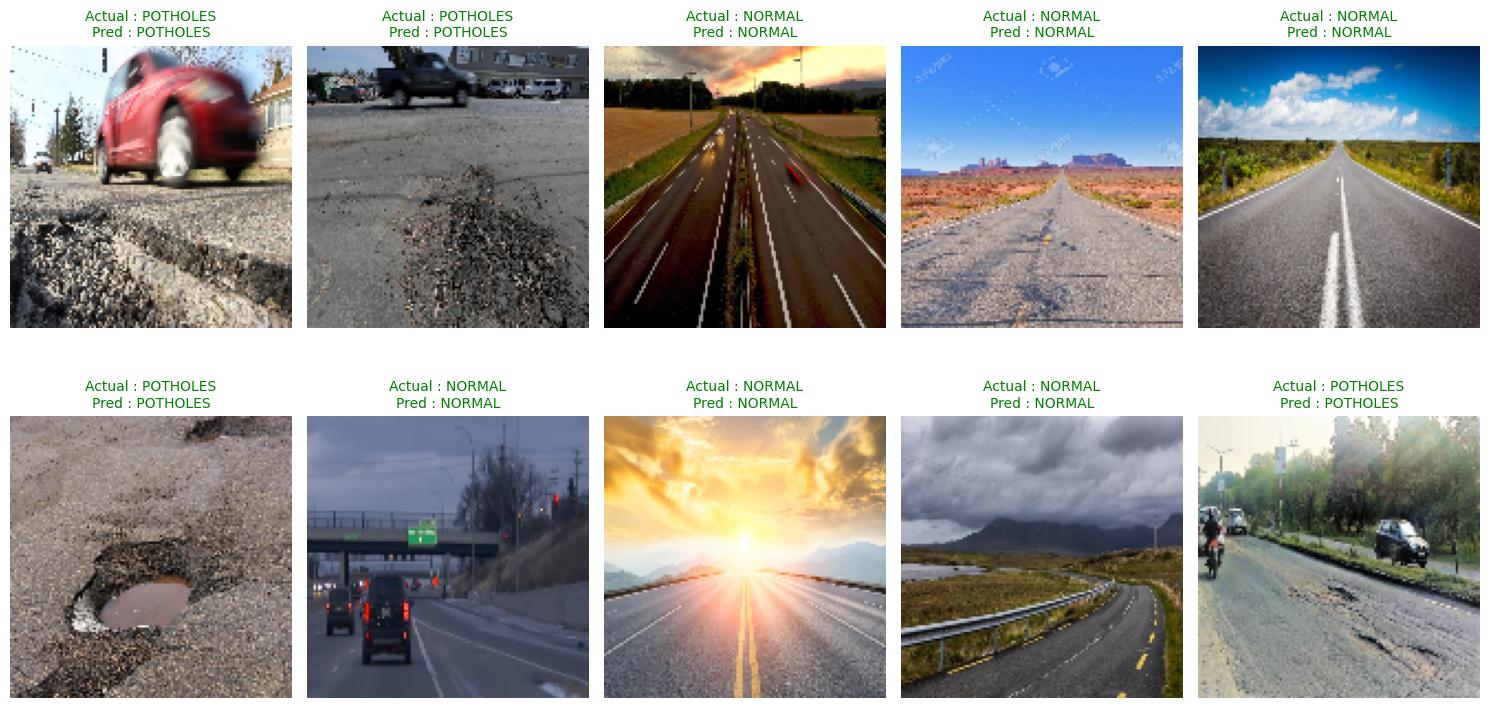

In [32]:
plt.figure(figsize=(15,8))

for i in range(10):

    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i])
    actual = classes[y_true[i]]
    predicted = classes[y_pred[i]]
    color = "green" if actual == predicted else "red"
    plt.title(
        f"Actual : {actual}\nPred : {predicted}",
        color=color,
        fontsize=10
    )
    plt.axis("off")
plt.tight_layout()
plt.savefig("sample_predictions.png")
plt.show()

In [31]:
def predict_image(image_path):

    img = cv2.imread(image_path)

    if img is None:
        print("Image not found.")
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (128,128))

    img = img.astype("float32") / 255.0

    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img, verbose=0)

    predicted_class = classes[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    plt.figure(figsize=(5,5))
    plt.imshow(img[0])
    plt.axis("off")
    plt.title(f"{predicted_class}\nConfidence: {confidence:.2f}%")
    plt.show()

    print(f"Prediction : {predicted_class}")
    print(f"Confidence : {confidence:.2f}%")